In [15]:

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
PALETTE = {"Normal": "#2196F3", "Risco": "#F44336"}
OUTPUT_DIR = "figures_bpm"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")


TensorFlow Version: 2.20.0
Matplotlib Version: 3.10.0


In [16]:

nome_arquivo = 'data/dataset2.csv'
df = pd.read_csv(nome_arquivo, sep=',')

df.columns = df.columns.str.replace('#', '').str.strip().str.lower()    
df.rename(columns={'heart_rate': 'bpm', 'activityid': 'target'}, inplace=True)

# Remove atividades transientes (ruído de transição entre atividades)
df = df[df['target'] != 'transient activities'].copy()

# Detecta quais fontes de dados estão presentes no dataset

HAS_STEPS    = 'steps' in df.columns
HAS_RR       = 'rr_interval' in df.columns
HAS_DEMO     = all(c in df.columns for c in ['age', 'sex'])
HAS_CLINICAL = any(c in df.columns for c in [
    'hist_hipertensao', 'hist_diabetes', 'hist_arritmia',
    'hist_infarto', 'hist_insuficiencia'
])

# TARGET: Redefinição para RISCO CARDÍACO
# 0 = Normal  (atividades de repouso/baixa intensidade)
# 1 = Risco   (atividades de alta intensidade)


le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])
df['target'] = df['target'].apply(lambda x: 0 if x <= 2 else 1)
df.dropna(inplace=True)

print(f"Dados carregados. Shape: {df.shape}")
print(f"\nFontes de dados detectadas no banco:")
print(f"  BPM (frequência cardíaca):  sempre disponível")
print(f"  Steps (acelerômetro):       {'✓ presente' if HAS_STEPS    else '✗ ausente — coluna: steps'}")
print(f"  RR interval (ECG beat):     {'✓ presente' if HAS_RR       else '✗ ausente — coluna: rr_interval'}")
print(f"  Demográfico (age, sex):     {'✓ presente' if HAS_DEMO     else '✗ ausente — colunas: age, sex'}")
print(f"  Histórico clínico:          {'✓ presente' if HAS_CLINICAL else '✗ ausente — colunas: hist_*'}")
print(f"\nDistribuição do target: {dict(zip(*np.unique(df['target'].values, return_counts=True)))}")


Dados carregados. Shape: (1936481, 33)

Fontes de dados detectadas no banco:
  BPM (frequência cardíaca):  sempre disponível
  Steps (acelerômetro):       ✗ ausente — coluna: steps
  RR interval (ECG beat):     ✗ ausente — coluna: rr_interval
  Demográfico (age, sex):     ✗ ausente — colunas: age, sex
  Histórico clínico:          ✗ ausente — colunas: hist_*

Distribuição do target: {np.int64(0): np.int64(469923), np.int64(1): np.int64(1466558)}


In [ ]:

# WINDOW_SIZE e STEP_SIZE são os principais hiperparâmetros
WINDOW_SIZE = 60
STEP_SIZE   = 30   # passo entre janelas; 30 = 50% de sobreposição

bpm_series = df['bpm'].values.astype(np.float32)
y_full     = df['target'].values

def make_windows(series, labels, window_size, step):
    # Janelas deslizantes (n, window_size, 1); label = classe do último ponto.
    X, y = [], []
    for i in range(0, len(series) - window_size + 1, step):
        X.append(series[i : i + window_size])
        y.append(labels[i + window_size - 1])
    return np.array(X, dtype=np.float32).reshape(-1, window_size, 1), np.array(y)

n_windows_est = len(range(0, len(bpm_series) - WINDOW_SIZE + 1, STEP_SIZE))
print(f"Série BPM:  {len(bpm_series):,} leituras")
print(f"WINDOW_SIZE={WINDOW_SIZE}  |  STEP_SIZE={STEP_SIZE}")
print(f"Janelas estimadas (treino+teste): ~{n_windows_est:,}")
print(f"Memória estimada (float32):       ~{n_windows_est * WINDOW_SIZE * 4 / 1e6:.1f} MB")


Série BPM:  1,936,481 leituras
WINDOW_SIZE=60  |  STEP_SIZE=30
Janelas estimadas (treino+teste): ~64,548
Memória estimada (float32):       ~15.5 MB


In [18]:

from sklearn.utils.class_weight import compute_class_weight

# Calcula pesos sobre o dataset original (antes do janelamento)
classes = np.unique(y_full)
cw = compute_class_weight('balanced', classes=classes, y=y_full)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, cw)}

counts = dict(zip(*np.unique(y_full, return_counts=True)))
total  = len(y_full)
print("=" * 58)
print("  DESBALANCEAMENTO (dataset original)")
print("=" * 58)
for cls, cnt in sorted(counts.items()):
    label = "Normal (0)" if cls == 0 else "Risco  (1)"
    print(f"  {label}: {cnt:>9,} amostras  ({cnt / total * 100:.1f}%)")
imbalance_ratio = max(counts.values()) / min(counts.values())
print(f"\n  Proporção majoritária / minoritária: {imbalance_ratio:.1f}:1")
print(f"  Pesos calculados (sklearn balanced): {class_weight_dict}")
print("=" * 58)


  DESBALANCEAMENTO (dataset original)
  Normal (0):   469,923 amostras  (24.3%)
  Risco  (1): 1,466,558 amostras  (75.7%)

  Proporção majoritária / minoritária: 3.1:1
  Pesos calculados (sklearn balanced): {0: 2.060423728993899, 1: 0.6602128930461666}


In [ ]:

# Divisão Cronológica
split_idx = int(len(bpm_series) * 0.7)

bpm_train_raw, y_train_raw = bpm_series[:split_idx], y_full[:split_idx]
bpm_test_raw,  y_test_raw  = bpm_series[split_idx:], y_full[split_idx:]

# Scaler calibrado somente no treino para evitar data leakage
scaler_bpm = StandardScaler()
bpm_train_s = scaler_bpm.fit_transform(bpm_train_raw.reshape(-1, 1)).flatten()
bpm_test_s  = scaler_bpm.transform(bpm_test_raw.reshape(-1, 1)).flatten()

X_train, y_train = make_windows(bpm_train_s, y_train_raw, WINDOW_SIZE, STEP_SIZE)
X_test,  y_test  = make_windows(bpm_test_s,  y_test_raw,  WINDOW_SIZE, STEP_SIZE)

print("Dados preparados:")
print(f"  X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")
dist_train = dict(zip(*np.unique(y_train, return_counts=True)))
dist_test  = dict(zip(*np.unique(y_test,  return_counts=True)))
print(f"  Distribuição treino: {dist_train}")
print(f"  Distribuição teste:  {dist_test}")


Dados preparados:
  X_train: (45183, 60, 1)  |  y_train: (45183,)
  X_test:  (19363, 60, 1)   |  y_test:  (19363,)
  Distribuição treino: {np.int64(0): np.int64(9588), np.int64(1): np.int64(35595)}
  Distribuição teste:  {np.int64(0): np.int64(6074), np.int64(1): np.int64(13289)}


In [ ]:

# Reamostragem - apenas no conjunto de treino
# SMOTE NÃO é recomendado para séries temporais (interpolar séries BPM cria padrões sem sentido)
# Opções válidas: 'undersample' | None
RESAMPLE_STRATEGY = 'None'

if RESAMPLE_STRATEGY == 'None':
    RESAMPLE_STRATEGY = None

if RESAMPLE_STRATEGY == 'undersample':
    from imblearn.under_sampling import RandomUnderSampler
    # RandomUnderSampler opera no eixo de amostras; achata 3D -> 2D, reamostra, reconstrói 3D
    n_s, win, n_f = X_train.shape
    rus = RandomUnderSampler(random_state=42, sampling_strategy=0.5)
    X_flat_r, y_train = rus.fit_resample(X_train.reshape(n_s, win * n_f), y_train)
    X_train = X_flat_r.reshape(-1, win, n_f)
    after = dict(zip(*np.unique(y_train, return_counts=True)))
    print(f"  'undersample' aplicado. Distribuição pós: {after}")
    print(f"  X_train após undersampling: {X_train.shape}")
else:
    before = dict(zip(*np.unique(y_train, return_counts=True)))
    print(f"  Reamostragem desativada. Distribuição de treino: {before}")


  Reamostragem desativada. Distribuição de treino: {np.int64(0): np.int64(9588), np.int64(1): np.int64(35595)}


In [ ]:

USE_FOCAL_LOSS = False   # com class_weight ativo o BCE já lida com o desbalanceamento

class BinaryFocalLoss(keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.75, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce     = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)
        return alpha_t * tf.pow(1 - p_t, self.gamma) * bce


# 'lstm' captura dependências de longo prazo; 'conv1d' detecta padrões locais
MODEL_TYPE = 'lstm'   # 'lstm' | 'conv1d'

input_seq = keras.Input(shape=(WINDOW_SIZE, 1), name='input_bpm_seq')

if MODEL_TYPE == 'lstm':
    x = layers.LSTM(64, return_sequences=True, name='lstm_1')(input_seq)
    x = layers.Dropout(0.3, name='lstm_dropout')(x)
    x = layers.LSTM(32, name='lstm_2')(x)
elif MODEL_TYPE == 'conv1d':
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='causal', name='conv1')(input_seq)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='causal', name='conv2')(x)
    x = layers.GlobalAveragePooling1D(name='global_pool')(x)

x      = layers.Dense(64, activation='relu', name='dense1')(x)
x      = layers.Dropout(0.2, name='dense_dropout')(x)
output = layers.Dense(1, activation='sigmoid', name='output')(x)

model = keras.Model(inputs=input_seq, outputs=output, name=f'bpm_{MODEL_TYPE}_model')

_focal_alpha = 0.5 if RESAMPLE_STRATEGY is not None else 0.75

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=BinaryFocalLoss(gamma=2.0, alpha=_focal_alpha) if USE_FOCAL_LOSS else 'binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(curve='PR', name='pr_auc')]
)

print(f"Modelo: {MODEL_TYPE.upper()}  |  Entrada: {X_train.shape[1:]}")
print(f"  Loss: {'Focal Loss' if USE_FOCAL_LOSS else 'Binary Cross-Entropy'}")
model.summary()


Modelo: LSTM  |  Entrada: (60, 1)
  Loss: Binary Cross-Entropy


Model: "bpm_lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_bpm_seq (InputLayer)      │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_dropout (Dropout)          │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dropout (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,489 (123.00 KB)

 Trainable params: 31,489 (123.00 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:

_class_weight = None if RESAMPLE_STRATEGY is not None else class_weight_dict

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, mode='min',
    restore_best_weights=True, verbose=1
)

print("  Compensação de desbalanceamento ativa:")
print(f"    Reamostragem:  {RESAMPLE_STRATEGY or 'nenhuma'}")
print(f"    class_weight:  {'desativado' if _class_weight is None else str(_class_weight)}")
print(f"    Focal alpha:   {_focal_alpha if USE_FOCAL_LOSS else 'N/A'}")
print()

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    class_weight=_class_weight,
    callbacks=[early_stop],
    verbose=1
)


  Compensação de desbalanceamento ativa:
    Reamostragem:  nenhuma
    class_weight:  {0: 2.060423728993899, 1: 0.6602128930461666}
    Focal alpha:   N/A

Epoch 1/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.7897 - loss: 0.3855 - pr_auc: 0.9681 - recall: 0.7590 - val_accuracy: 0.8841 - val_loss: 0.3034 - val_pr_auc: 0.9744 - val_recall: 0.9024
Epoch 2/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.7967 - loss: 0.3730 - pr_auc: 0.9707 - recall: 0.7687 - val_accuracy: 0.8809 - val_loss: 0.3104 - val_pr_auc: 0.9770 - val_recall: 0.8875
Epoch 3/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.7974 - loss: 0.3721 - pr_auc: 0.9708 - recall: 0.7694 - val_accuracy: 0.8388 - val_loss: 0.3375 - val_pr_auc: 0.9733 - val_recall: 0.8324
Epoch 4/50
565/565 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.7976 - loss: 0.3690 - pr_auc: 0.9716 - recall: 0.7694 - val_accuracy: 0.8353 - val_loss: 0.3390 - val_pr_auc: 0.9716 - val_recall: 0.8321
Epoch 5/50
565/565 

In [ ]:

from sklearn.metrics import average_precision_score

probs_anomalia = model.predict(X_test).flatten()
probs_normal   = 1.0 - probs_anomalia

pr_auc_risco = average_precision_score(y_test, probs_anomalia, pos_label=1)

# Otimiza threshold via F1-macro - equilíbrio entre Normal e Risco sem penalizar uma classe
threshold_candidates = np.linspace(0.01, 0.99, 200)
f1_macro_scores = [
    f1_score(y_test, np.where(probs_anomalia >= t, 1, 0), average='macro', zero_division=0)
    for t in threshold_candidates
]
best_idx  = int(np.argmax(f1_macro_scores))
THRESHOLD = float(threshold_candidates[best_idx])

print(f"  Threshold otimizado (F1-macro):  {THRESHOLD:.4f}")
print(f"  PR-AUC (classe Risco):           {pr_auc_risco:.4f}")

preds_custom = np.where(probs_anomalia >= THRESHOLD, 1, 0)

print(f"\n--- Resultados: {MODEL_TYPE.upper()} BPM-Only ---")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, preds_custom))
print(f"\nRelatório de Classificação (Threshold = {THRESHOLD:.4f}):")
print(classification_report(y_test, preds_custom, target_names=['Normal (0)', 'Anômalo/Risco (1)']))


606/606 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step
  Threshold otimizado (F1-macro):  0.7733
  PR-AUC (classe Risco):           0.9506

--- Resultados: LSTM BPM-Only ---

Matriz de Confusão:
[[ 5295   779]
 [ 2375 10914]]

Relatório de Classificação (Threshold = 0.7733):
                   precision    recall  f1-score   support

       Normal (0)       0.69      0.87      0.77      6074
Anômalo/Risco (1)       0.93      0.82      0.87     13289

         accuracy                           0.84     19363
        macro avg       0.81      0.85      0.82     19363
     weighted avg       0.86      0.84      0.84     19363



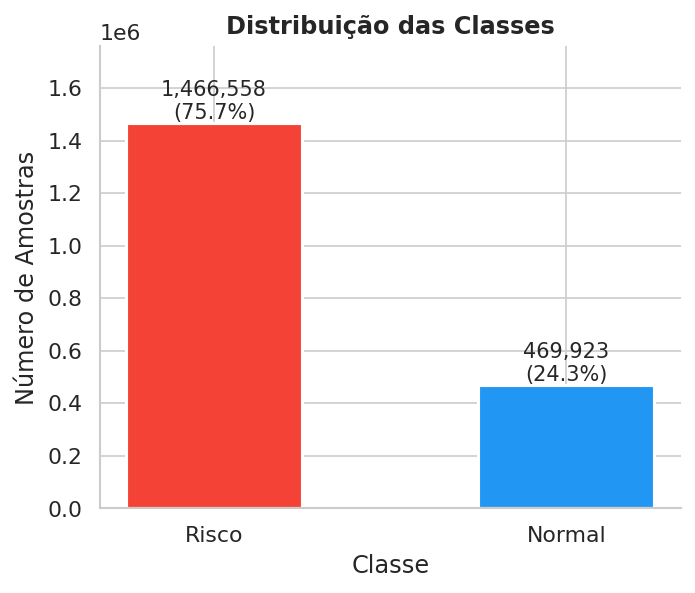

  Salvo: figures_bpm/01_class_distribution.png


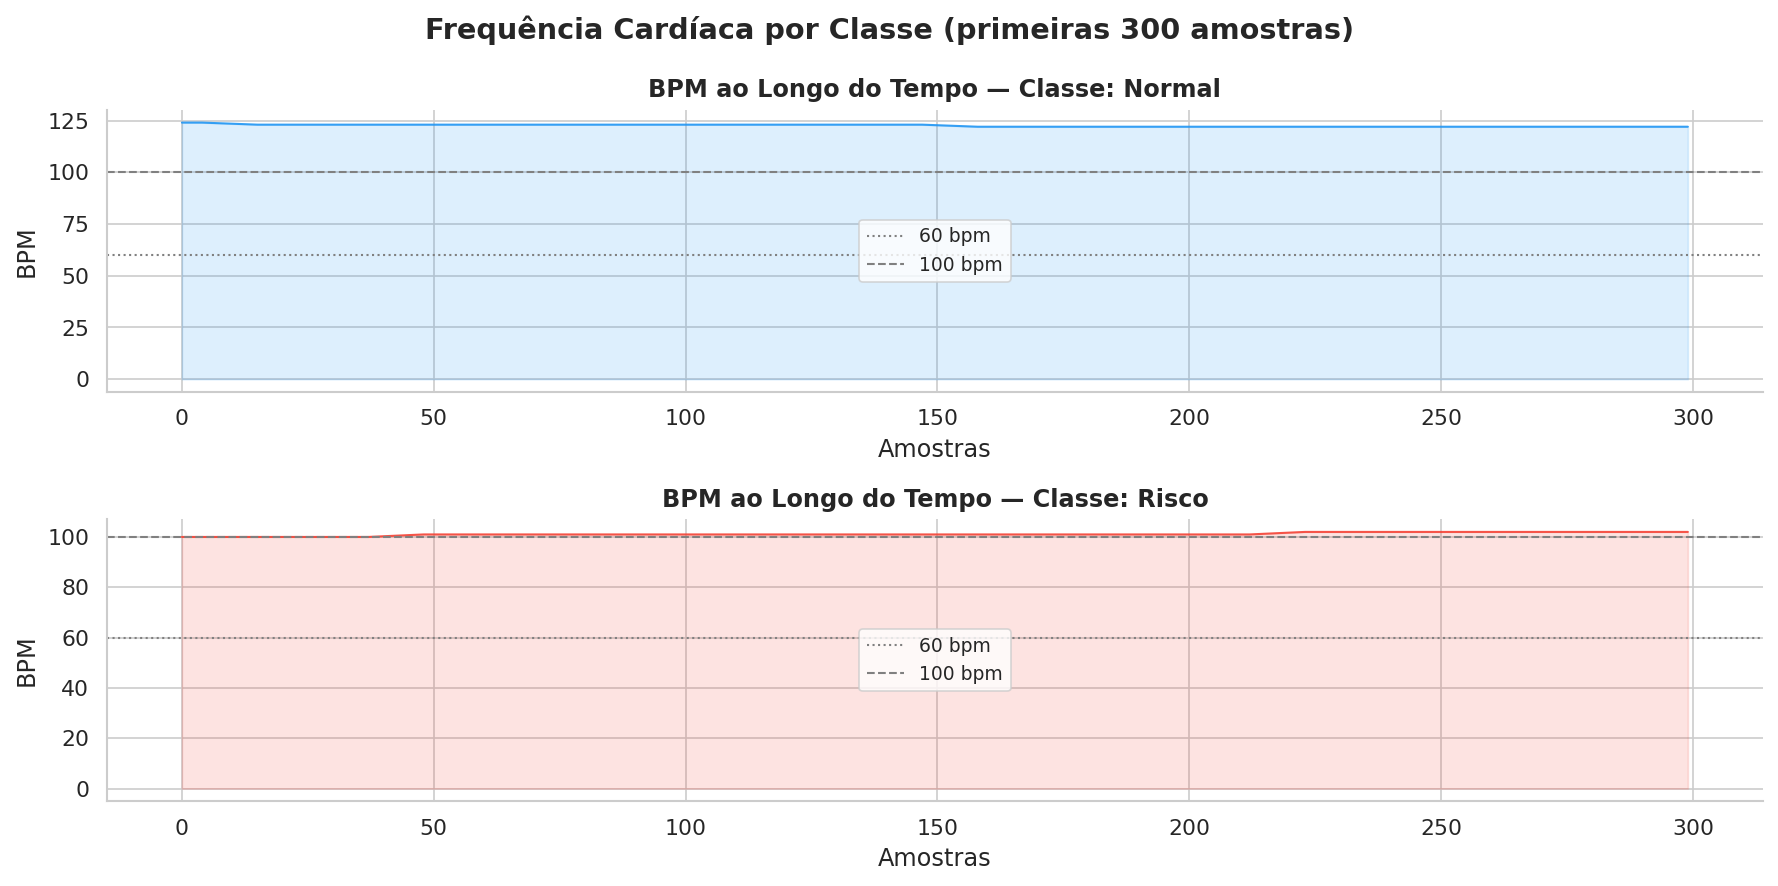

  Salvo: figures_bpm/02_bpm_over_time.png


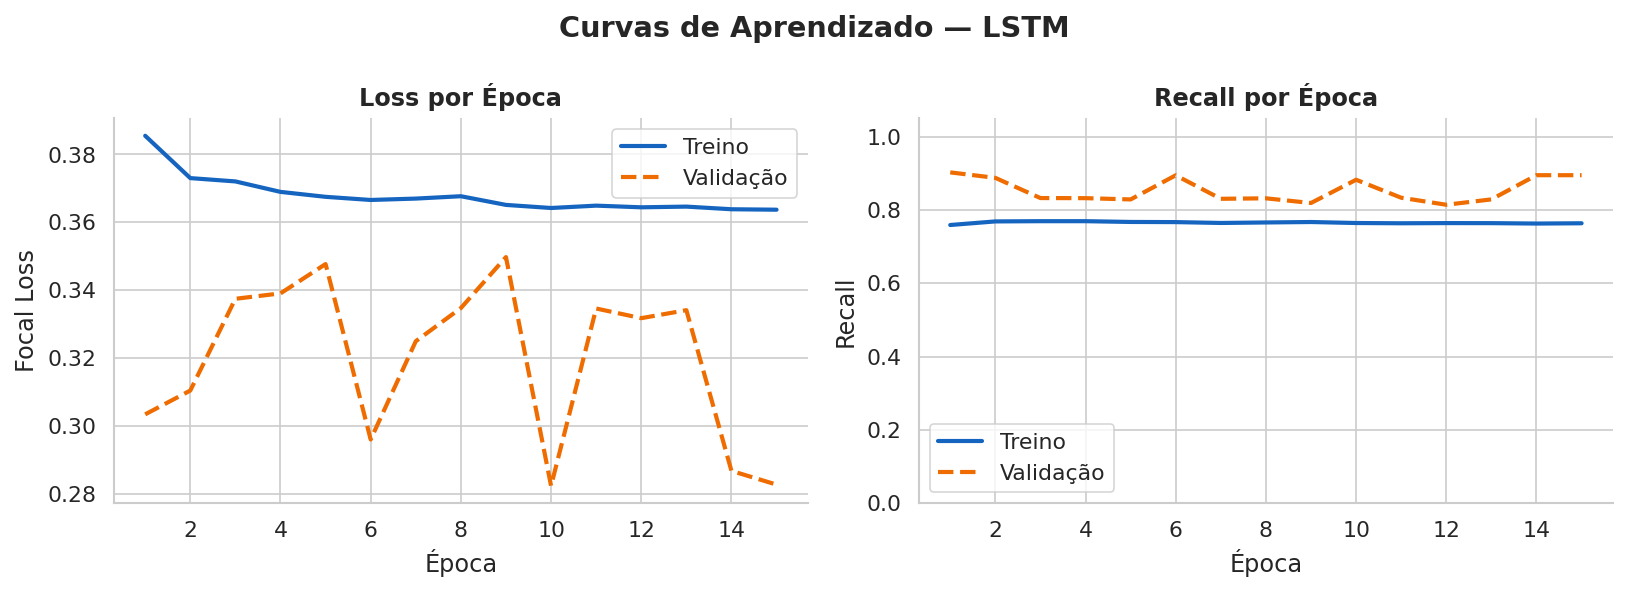

  Salvo: figures_bpm/03_training_curves.png


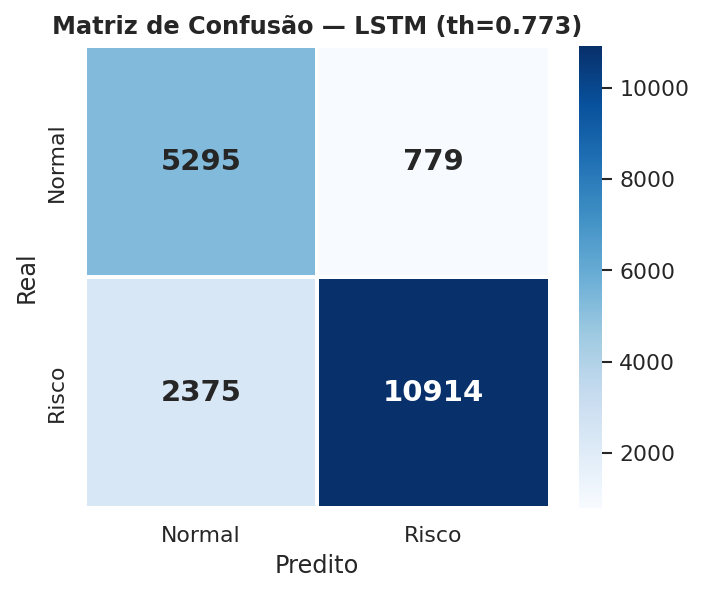

  Salvo: figures_bpm/04_confusion_matrix.png

  Gráficos 01-04 salvos em: ./figures_bpm/


In [24]:

label_map  = {0: "Normal", 1: "Risco"}
target_col = pd.Series(y_full, name="target").map(label_map)

def save_fig(name):
    path = f"{OUTPUT_DIR}/{name}.png"
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"  Salvo: {path}")


# Distribuição das classes (dataset original)
fig, ax = plt.subplots(figsize=(5, 4))
counts_plot = target_col.value_counts()
bars = ax.bar(counts_plot.index, counts_plot.values,
              color=[PALETTE[l] for l in counts_plot.index],
              width=0.5, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts_plot.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{val:,}\n({val/len(target_col)*100:.1f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_title("Distribuição das Classes", fontweight="bold")
ax.set_ylabel("Número de Amostras")
ax.set_xlabel("Classe")
ax.set_ylim(0, counts_plot.max() * 1.2)
save_fig("01_class_distribution")


# BPM ao longo do tempo
N_SAMPLE = 300
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

for ax, (lbl, color) in zip(axes, [("Normal", "#2196F3"), ("Risco", "#F44336")]):
    subset = df[df['target'] == (0 if lbl == "Normal" else 1)]['bpm'].head(N_SAMPLE)
    ax.plot(subset.values, color=color, linewidth=1, alpha=0.9)
    ax.fill_between(range(len(subset)), subset.values, alpha=0.15, color=color)
    ax.axhline(60,  color="gray", linestyle=":", linewidth=1, label="60 bpm")
    ax.axhline(100, color="gray", linestyle="--", linewidth=1, label="100 bpm")
    ax.set_title(f"BPM ao Longo do Tempo — Classe: {lbl}", fontweight="bold")
    ax.set_ylabel("BPM")
    ax.set_xlabel("Amostras")
    ax.legend(fontsize=9)

plt.suptitle("Frequência Cardíaca por Classe (primeiras 300 amostras)", fontweight="bold")
plt.tight_layout()
save_fig("02_bpm_over_time")


# Curvas de treino
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
epochs_range = range(1, len(history.history['loss']) + 1)

ax1.plot(epochs_range, history.history['loss'],    color="#1565C0", label="Treino",    linewidth=2)
ax1.plot(epochs_range, history.history['val_loss'], color="#EF6C00", label="Validação", linewidth=2, linestyle="--")
ax1.set_title("Loss por Época", fontweight="bold")
ax1.set_xlabel("Época")
ax1.set_ylabel("Focal Loss")
ax1.legend()

ax2.plot(epochs_range, history.history['recall'],    color="#1565C0", label="Treino",    linewidth=2)
ax2.plot(epochs_range, history.history['val_recall'], color="#EF6C00", label="Validação", linewidth=2, linestyle="--")
ax2.set_title("Recall por Época", fontweight="bold")
ax2.set_xlabel("Época")
ax2.set_ylabel("Recall")
ax2.set_ylim(0, 1.05)
ax2.legend()

plt.suptitle(f"Curvas de Aprendizado — {MODEL_TYPE.upper()}", fontweight="bold")
plt.tight_layout()
save_fig("03_training_curves")


# Matriz de confusão
cm = confusion_matrix(y_test, preds_custom)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Risco"],
    yticklabels=["Normal", "Risco"],
    linewidths=1, linecolor="white", ax=ax,
    annot_kws={"size": 14, "weight": "bold"}
)
ax.set_title(f"Matriz de Confusão — {MODEL_TYPE.upper()} (th={THRESHOLD:.3f})", fontweight="bold")
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
save_fig("04_confusion_matrix")

print(f"\n  Gráficos 01-04 salvos em: ./{OUTPUT_DIR}/")


In [ ]:

print("\n" + "="*60)
print("   BASELINES DE COMPARAÇÃO")
print("="*60)
print("Modelos clássicos recebem as mesmas janelas em formato achatado (2D).")
print("Comparação justa: mesma informação, arquitetura diferente.\n")

# Achata 3D -> 2D para modelos sem processamento sequencial
X_train_flat = X_train.reshape(len(X_train), -1)   # (n, WINDOW_SIZE)
X_test_flat  = X_test.reshape(len(X_test),  -1)

def print_baseline_results(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print("Matriz de Confusão:")
    print(confusion_matrix(y_true, y_pred))
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred,
                                target_names=['Normal (0)', 'Anômalo/Risco (1)'],
                                zero_division=0))


# Baseline 1: Rede Dense (janela achatada sem memória sequencial)
print("  Treinando Dense baseline...")
inp_b   = keras.Input(shape=(WINDOW_SIZE,), name='input_flat')
x_b     = layers.Dense(64, activation='relu')(inp_b)
x_b     = layers.Dropout(0.2)(x_b)
x_b     = layers.Dense(32, activation='relu')(x_b)
out_b   = layers.Dense(1, activation='sigmoid')(x_b)
model_dense = keras.Model(inputs=inp_b, outputs=out_b, name='dense_baseline')
model_dense.compile(
    optimizer='adam', loss='binary_crossentropy',
    metrics=[keras.metrics.Recall(name='recall')]
)
model_dense.fit(
    X_train_flat, y_train, epochs=20, batch_size=64,
    validation_split=0.2, class_weight=class_weight_dict,
    callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=0
)
dense_probs = model_dense.predict(X_test_flat).flatten()
dense_preds = np.where(dense_probs >= THRESHOLD, 1, 0)
print_baseline_results(f"Baseline 1: Dense BPM-window (th={THRESHOLD:.3f})", y_test, dense_preds)


# Baseline 2: Regressão Logística
log_reg = LogisticRegression(class_weight=class_weight_dict, random_state=42, max_iter=1000)
log_reg.fit(X_train_flat, y_train)
log_preds = log_reg.predict(X_test_flat)
print_baseline_results("Baseline 2: Regressão Logística (janela achatada)", y_test, log_preds)


# Baseline 3: Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight=class_weight_dict,
    random_state=42, n_jobs=-1,
)
rf_clf.fit(X_train_flat, y_train)
rf_probs = rf_clf.predict_proba(X_test_flat)[:, 1]
rf_preds = np.where(rf_probs >= THRESHOLD, 1, 0)
print_baseline_results(f"Baseline 3: Random Forest (th={THRESHOLD:.3f})", y_test, rf_preds)



   BASELINES DE COMPARAÇÃO
Modelos clássicos recebem as mesmas janelas em formato achatado (2D).
Comparação justa: mesma informação, arquitetura diferente.

  Treinando Dense baseline...
606/606 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step

--- Baseline 1: Dense BPM-window (th=0.773) ---
Matriz de Confusão:
[[5332  742]
 [3579 9710]]

Relatório de Classificação:
                   precision    recall  f1-score   support

       Normal (0)       0.60      0.88      0.71      6074
Anômalo/Risco (1)       0.93      0.73      0.82     13289

         accuracy                           0.78     19363
        macro avg       0.76      0.80      0.76     19363
     weighted avg       0.83      0.78      0.78     19363


--- Baseline 2: Regressão Logística (janela achatada) ---
Matriz de Confusão:
[[ 3942  2132]
 [ 2831 10458]]

Relatório de Classificação:
                   precision    recall  f1-score   support

       Normal (0)       0.58      0.65      0.61      6074
Anômalo/Risco (1)       0.83 

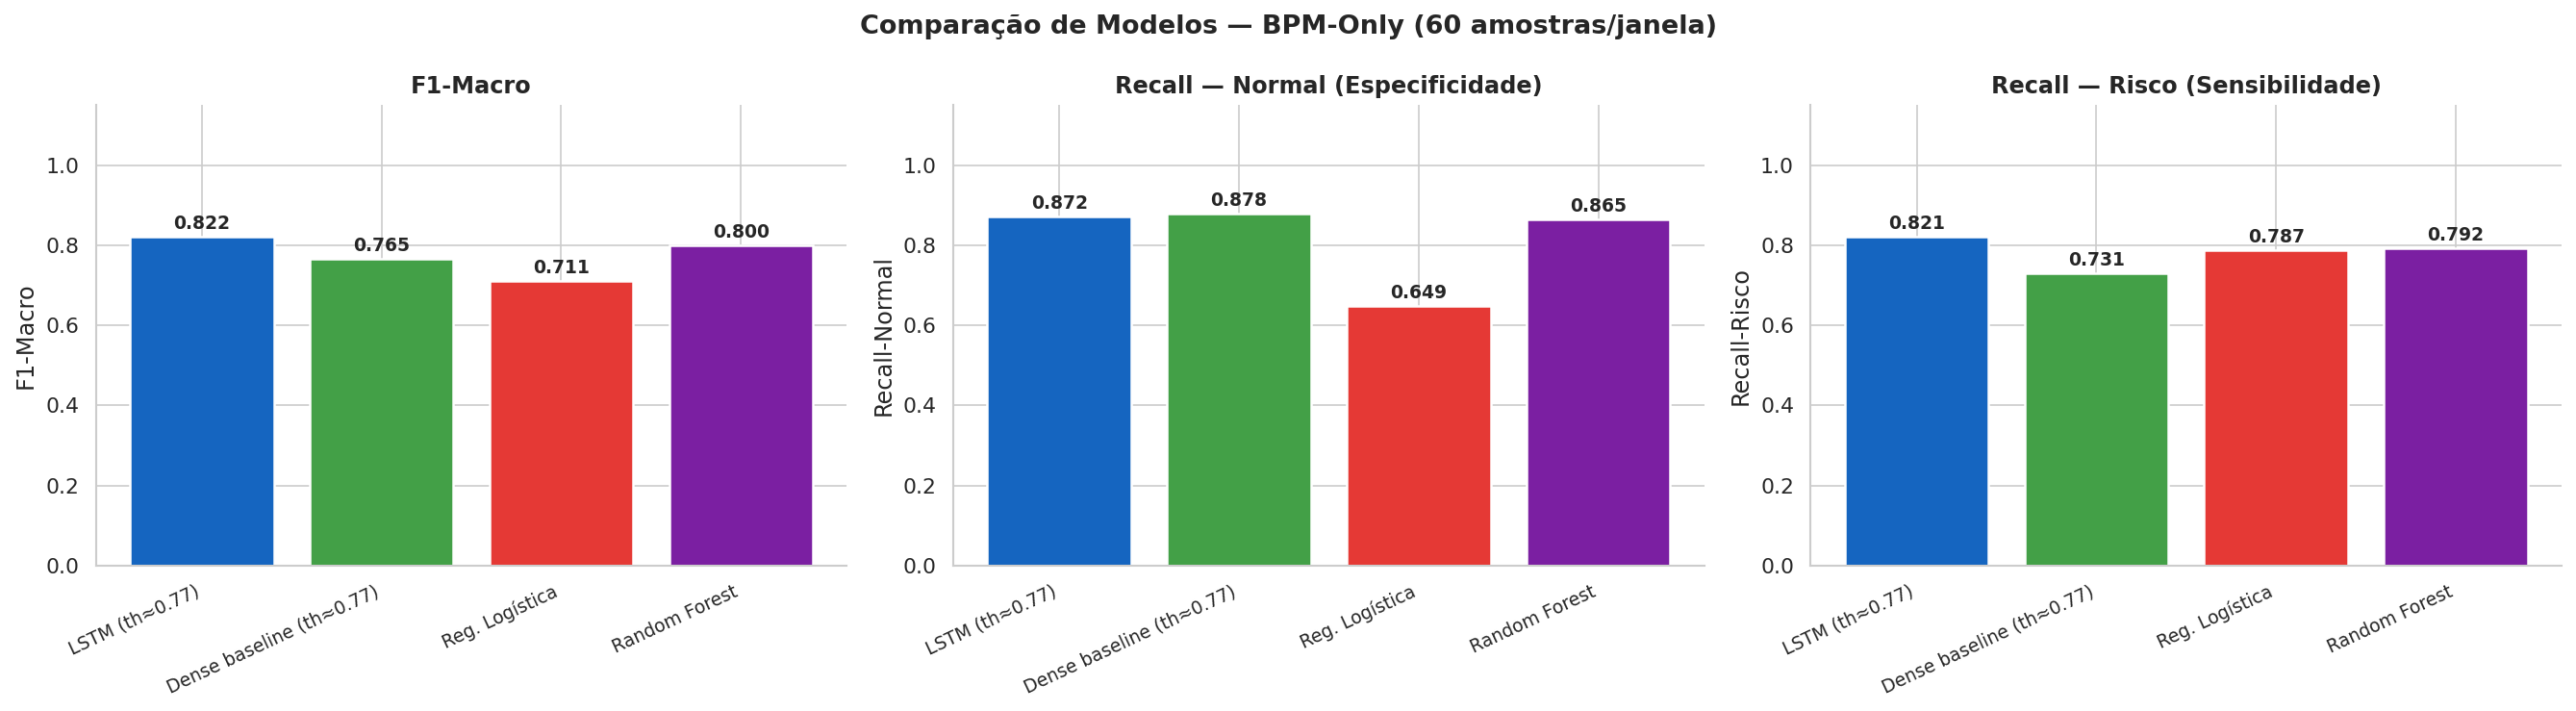

  Salvo: figures_bpm/05_model_comparison.png

   MÉTRICA DE PENALIDADE CLÍNICA (penalty=10)
  Modelo                                 | Score Clínico
  -------------------------------------------------------
  LSTM (th≈0.77)                         | 0.8259  (Recall-Risco=0.821, Recall-Normal=0.872)
  Dense baseline (th≈0.77)               | 0.7441  (Recall-Risco=0.731, Recall-Normal=0.878)
  Reg. Logística                         | 0.7744  (Recall-Risco=0.787, Recall-Normal=0.649)
  Random Forest                          | 0.7990  (Recall-Risco=0.792, Recall-Normal=0.865)

  Fórmula: (10 × Recall-Risco + Recall-Normal) / 11

                  Modelo  F1-Macro  Recall-Normal  Recall-Risco  Acurácia
          LSTM (th≈0.77)     0.822          0.872         0.821     0.837
Dense baseline (th≈0.77)     0.765          0.878         0.731     0.777
          Reg. Logística     0.711          0.649         0.787     0.744
           Random Forest     0.800          0.865         0.792     0.8

In [26]:

# Conjunto centralizado de modelos e predições para comparação
all_eval = [
    (f"{MODEL_TYPE.upper()} (th≈{THRESHOLD:.2f})", preds_custom),
    (f"Dense baseline (th≈{THRESHOLD:.2f})",       dense_preds),
    ("Reg. Logística",                             log_preds),
    ("Random Forest",                              rf_preds),
]

def model_metrics(y_true, y_pred, name):
    return {
        "Modelo":        name,
        "F1-Macro":      round(f1_score(y_true, y_pred, average="macro", zero_division=0), 3),
        "Recall-Normal": round(recall_score(y_true, y_pred, pos_label=0, zero_division=0), 3),
        "Recall-Risco":  round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 3),
        "Acurácia":      round((y_pred == y_true).mean(), 3),
    }

def clinical_score(y_true, y_pred, penalty=10):
    r_risco  = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    r_normal = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    return (penalty * r_risco + r_normal) / (penalty + 1)

metrics_list = [model_metrics(y_test, preds, name) for name, preds in all_eval]
df_metrics = pd.DataFrame(metrics_list)
bar_colors  = ["#1565C0", "#43A047", "#E53935", "#7B1FA2"]

metric_cols   = ["F1-Macro", "Recall-Normal", "Recall-Risco"]
metric_titles = ["F1-Macro", "Recall — Normal (Especificidade)", "Recall — Risco (Sensibilidade)"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in zip(axes, metric_cols, metric_titles):
    bars = ax.bar(df_metrics["Modelo"], df_metrics[col],
                  color=bar_colors[:len(df_metrics)], edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, df_metrics[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01, f"{val:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(col)
    ax.set_xticklabels(df_metrics["Modelo"], rotation=25, ha="right", fontsize=9)

plt.suptitle(f"Comparação de Modelos — BPM-Only ({WINDOW_SIZE} amostras/janela)", fontweight="bold", fontsize=13)
plt.tight_layout()
save_fig("05_model_comparison")

print("\n" + "="*60)
print("   MÉTRICA DE PENALIDADE CLÍNICA (penalty=10)")
print("="*60)
print(f"  {'Modelo':<38} | Score Clínico")
print("  " + "-"*55)
for name, preds in all_eval:
    s  = clinical_score(y_test, preds)
    rr = recall_score(y_test, preds, pos_label=1, zero_division=0)
    rn = recall_score(y_test, preds, pos_label=0, zero_division=0)
    print(f"  {name:<38} | {s:.4f}  (Recall-Risco={rr:.3f}, Recall-Normal={rn:.3f})")

print("\n  Fórmula: (10 × Recall-Risco + Recall-Normal) / 11")
print()
print(df_metrics.to_string(index=False))



   ANÁLISE DE SENSIBILIDADE — TAMANHO DA JANELA
Testa Regressão Logística como proxy rápido para escolher WINDOW_SIZE
antes de treinar o LSTM completo (muito mais barato computacionalmente).

 WINDOW_SIZE  F1-Macro  Recall-Risco  Amostras treino
          30     0.710         0.788            90368
          60     0.711         0.787            45183
         120     0.713         0.787            22591
         300     0.720         0.788             9035


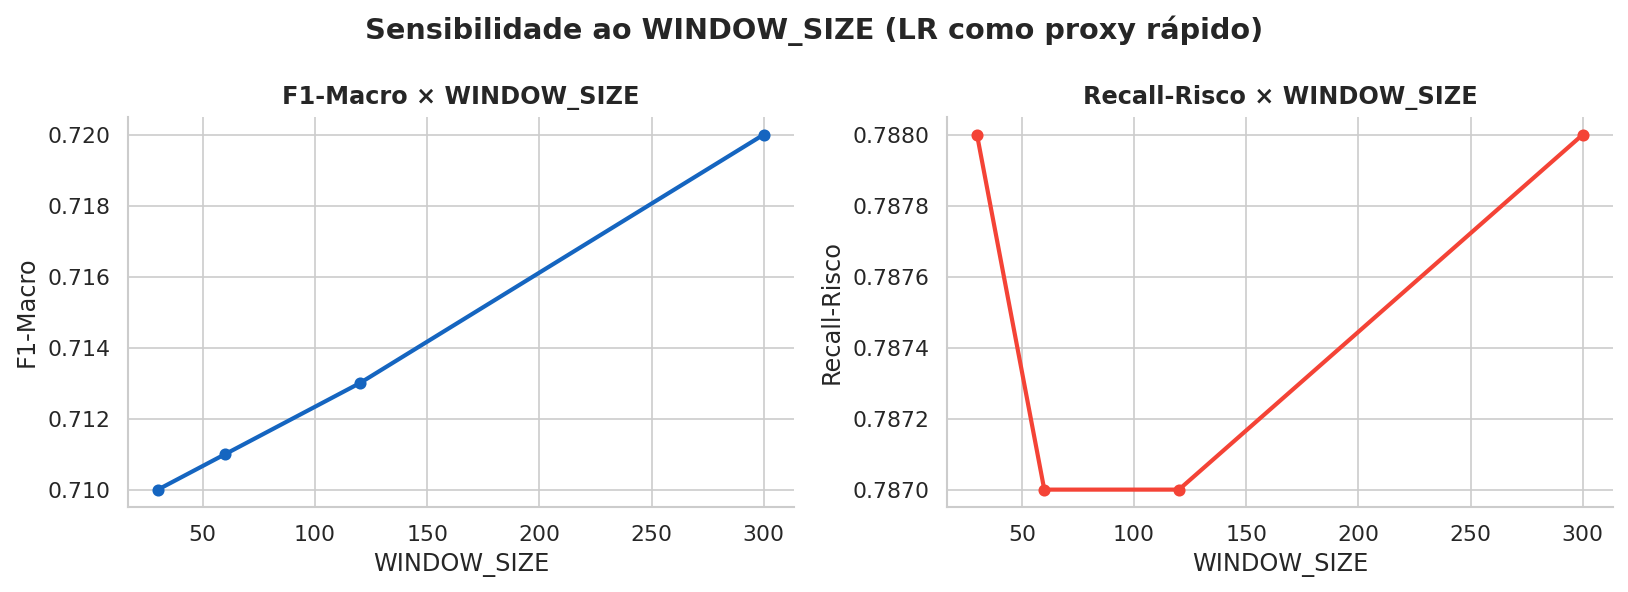

  Salvo: figures_bpm/06_window_size_sensitivity.png

  WINDOW_SIZE atual no modelo principal: 60
  Ajuste WINDOW_SIZE na célula 3 com base nos resultados acima e re-execute.


In [27]:

print("\n" + "="*60)
print("   ANÁLISE DE SENSIBILIDADE — TAMANHO DA JANELA")
print("="*60)
print("Testa Regressão Logística como proxy rápido para escolher WINDOW_SIZE")
print("antes de treinar o LSTM completo (muito mais barato computacionalmente).\n")

window_sizes_test = [30, 60, 120, 300]
results_ws = []

for ws in window_sizes_test:
    step = ws // 2
    X_tr_ws, y_tr_ws = make_windows(bpm_train_s, y_train_raw, ws, step)
    X_te_ws, y_te_ws = make_windows(bpm_test_s,  y_test_raw,  ws, step)
    X_tr_f = X_tr_ws.reshape(len(X_tr_ws), -1)
    X_te_f = X_te_ws.reshape(len(X_te_ws), -1)
    clf = LogisticRegression(class_weight=class_weight_dict, random_state=42, max_iter=500)
    clf.fit(X_tr_f, y_tr_ws)
    preds_ws = clf.predict(X_te_f)
    f1  = f1_score(y_te_ws, preds_ws, average='macro', zero_division=0)
    rr  = recall_score(y_te_ws, preds_ws, pos_label=1, zero_division=0)
    results_ws.append({
        "WINDOW_SIZE":    ws,
        "F1-Macro":       round(f1, 3),
        "Recall-Risco":   round(rr, 3),
        "Amostras treino": len(y_tr_ws),
    })

df_ws = pd.DataFrame(results_ws)
print(df_ws.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(df_ws["WINDOW_SIZE"], df_ws["F1-Macro"],     "o-", color="#1565C0", linewidth=2)
ax1.set_title("F1-Macro × WINDOW_SIZE", fontweight="bold")
ax1.set_xlabel("WINDOW_SIZE")
ax1.set_ylabel("F1-Macro")

ax2.plot(df_ws["WINDOW_SIZE"], df_ws["Recall-Risco"], "o-", color="#F44336", linewidth=2)
ax2.set_title("Recall-Risco × WINDOW_SIZE", fontweight="bold")
ax2.set_xlabel("WINDOW_SIZE")
ax2.set_ylabel("Recall-Risco")

plt.suptitle("Sensibilidade ao WINDOW_SIZE (LR como proxy rápido)", fontweight="bold")
plt.tight_layout()
save_fig("06_window_size_sensitivity")

print(f"\n  WINDOW_SIZE atual no modelo principal: {WINDOW_SIZE}")
print("  Ajuste WINDOW_SIZE na célula 3 com base nos resultados acima e re-execute.")


In [28]:

model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

model.save(f"{model_dir}/bpm_{MODEL_TYPE}_w{WINDOW_SIZE}_model.keras")
joblib.dump(scaler_bpm, f"{model_dir}/bpm_scaler.pkl")

model_config = {
    'model_type':  MODEL_TYPE,
    'window_size': WINDOW_SIZE,
    'step_size':   STEP_SIZE,
    'threshold':   THRESHOLD,
}
joblib.dump(model_config, f"{model_dir}/bpm_model_config.pkl")

print("Modelo e artefatos salvos:")
print(f"  - {model_dir}/bpm_{MODEL_TYPE}_w{WINDOW_SIZE}_model.keras")
print(f"  - {model_dir}/bpm_scaler.pkl")
print(f"  - {model_dir}/bpm_model_config.pkl")


Modelo e artefatos salvos:
  - models/bpm_lstm_w60_model.keras
  - models/bpm_scaler.pkl
  - models/bpm_model_config.pkl
